# Plotter

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
from defermi import DefectsAnalysis

bulk_volume = 800 # cubic Amstrong
data = [
{'name': 'Vac_O','charge': 2,'multiplicity': 1,'energy_diff': 7,'bulk_volume': bulk_volume},
{'name': 'Vac_O','charge':0,'multiplicity':1,'energy_diff': 10.8, 'bulk_volume': bulk_volume},
{'name': 'Vac_Sr','charge': -2,'multiplicity': 1,'energy_diff': 8,'bulk_volume': bulk_volume},
{'name': 'Vac_Sr','charge': 0,'multiplicity': 1,'energy_diff': 7.8,'bulk_volume': bulk_volume},
{'name': 'Vac_Ti','charge': -4,'multiplicity': 1,'energy_diff': 20,'bulk_volume': bulk_volume},
{'name': 'Vac_Ti','charge': 0,'multiplicity': 1,'energy_diff': 19.7,'bulk_volume': bulk_volume},
{'name': 'Sub_Fe_on_Ti','charge': -1,'multiplicity': 1,'energy_diff': 6.5,'bulk_volume': bulk_volume},
{'name': 'Sub_Fe_on_Ti','charge': -2,'multiplicity': 1,'energy_diff': 7.5,'bulk_volume': bulk_volume},
{'name': 'Sub_Nb_on_Ti','charge': 1,'multiplicity': 1,'energy_diff': 2,'bulk_volume': bulk_volume},
{'name': 'Sub_Nb_on_Ti','charge': 0,'multiplicity': 1,'energy_diff': 3.5,'bulk_volume': bulk_volume},
]
df = pd.DataFrame(data)
da = DefectsAnalysis.from_dataframe(df,band_gap=2.0,vbm=0.0)
da.table(display=['energy_diff'])

,name,delta atoms,charge,multiplicity,corrections,energy_diff
0,Sub_Fe_on_Ti,"{'Fe': 1, 'Ti': -1}",-2,1,{},7.5
1,Sub_Fe_on_Ti,"{'Fe': 1, 'Ti': -1}",-1,1,{},6.5
2,Sub_Nb_on_Ti,"{'Nb': 1, 'Ti': -1}",0,1,{},3.5
3,Sub_Nb_on_Ti,"{'Nb': 1, 'Ti': -1}",1,1,{},2.0
4,Vac_O,{'O': -1},0,1,{},10.8
5,Vac_O,{'O': -1},2,1,{},7.0
6,Vac_Sr,{'Sr': -1},-2,1,{},8.0
7,Vac_Sr,{'Sr': -1},0,1,{},7.8
8,Vac_Ti,{'Ti': -1},-4,1,{},20.0
9,Vac_Ti,{'Ti': -1},0,1,{},19.7


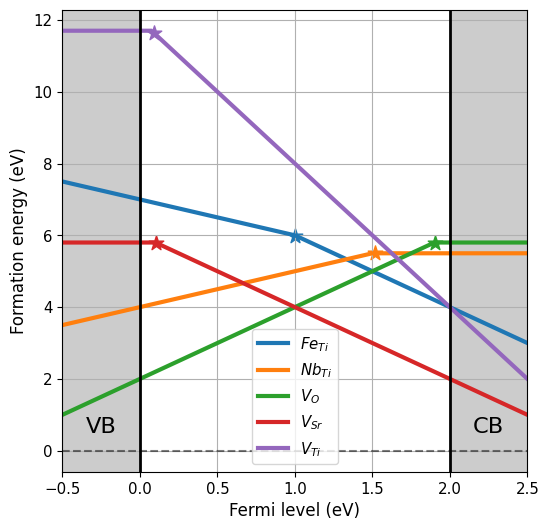

In [3]:
chempots = {'O':-5,'Sr':-2,'Fe':-8.5,'Ti':-8,'Nb':-10}
bulk_dos = {'m_eff_e':0.5,'m_eff_h':0.4}
da.plot_formation_energies(chempots);

In [4]:
da_Fe = da.filter_entries(exclude=True,elements=['Nb'])
da_Fe

,name,delta atoms,charge,multiplicity,corrections
0,Sub_Fe_on_Ti,"{'Fe': 1, 'Ti': -1}",-2,1,{}
1,Sub_Fe_on_Ti,"{'Fe': 1, 'Ti': -1}",-1,1,{}
2,Vac_O,{'O': -1},0,1,{}
3,Vac_O,{'O': -1},2,1,{}
4,Vac_Sr,{'Sr': -1},-2,1,{}
5,Vac_Sr,{'Sr': -1},0,1,{}
6,Vac_Ti,{'Ti': -1},-4,1,{}
7,Vac_Ti,{'Ti': -1},0,1,{}


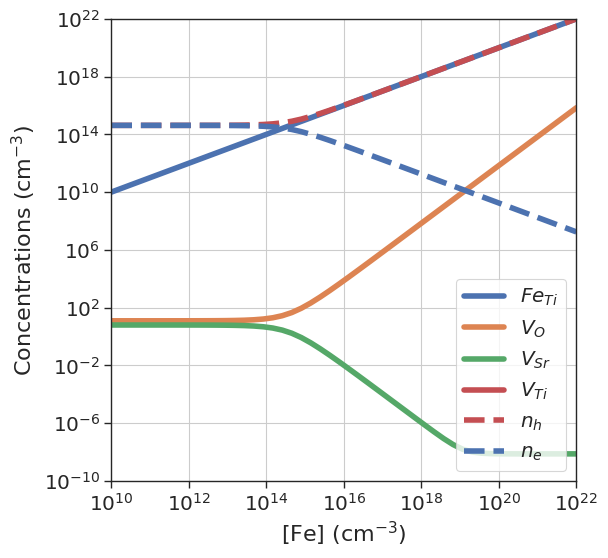

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns # optional

sns.set_theme(context='paper',style='ticks') # optional


da_Fe.plot_doping_diagram(
                    variable_defect_specie='Fe',
                    concentration_range=(1e10,1e22),
                    chemical_potentials=chempots,
                    bulk_dos=bulk_dos,
                    temperature=1000,
                    figsize=(6,6),
                    fontsize=16,
                    ylim=(1e-10,1e22)
                    );
data_Fe = da_Fe.thermodata

In [6]:
da_Nb = da.filter_entries(exclude=True,elements=['Fe'])
da_Nb

,name,delta atoms,charge,multiplicity,corrections
0,Sub_Nb_on_Ti,"{'Nb': 1, 'Ti': -1}",0,1,{}
1,Sub_Nb_on_Ti,"{'Nb': 1, 'Ti': -1}",1,1,{}
2,Vac_O,{'O': -1},0,1,{}
3,Vac_O,{'O': -1},2,1,{}
4,Vac_Sr,{'Sr': -1},-2,1,{}
5,Vac_Sr,{'Sr': -1},0,1,{}
6,Vac_Ti,{'Ti': -1},-4,1,{}
7,Vac_Ti,{'Ti': -1},0,1,{}


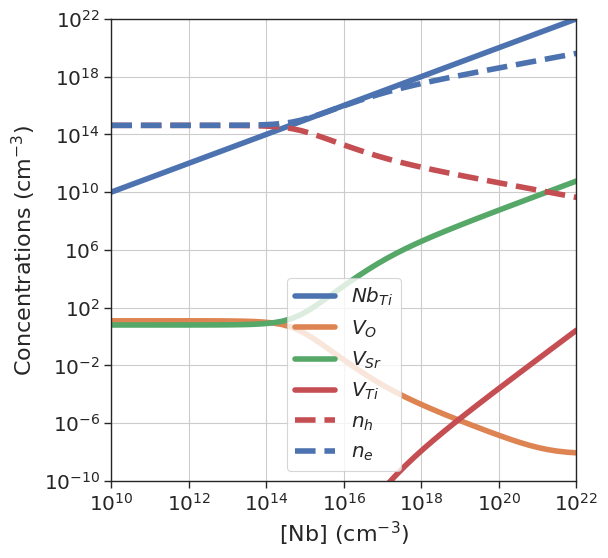

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns # optional

sns.set_theme(context='paper',style='ticks') # optional


da_Nb.plot_doping_diagram(
                    variable_defect_specie='Nb',
                    concentration_range=(1e10,1e22),
                    chemical_potentials=chempots,
                    bulk_dos=bulk_dos,
                    temperature=1000,
                    figsize=(6,6),
                    fontsize=16,
                    ylim=(1e-10,1e22)
                    );
data_Nb = da_Nb.thermodata

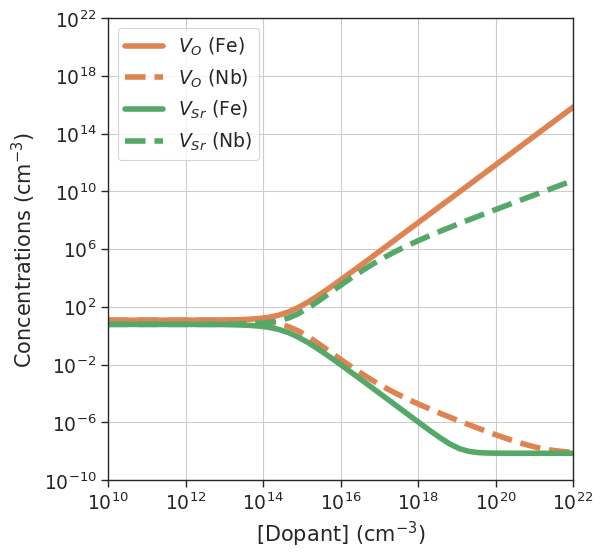

In [8]:
from defermi.plotter import plot_x_vs_concentrations
import matplotlib

fig,ax = plt.subplots(figsize=(6,6))
fontsize = 15

X = data_Fe.variable_concentrations # Nb are equivalent

# get individual total concentrations
Vac_O_Fe = [c.total['Vac_O'] for c in data_Fe.defect_concentrations]
Vac_O_Nb = [c.total['Vac_O'] for c in data_Nb.defect_concentrations]
Vac_Sr_Fe = [c.total['Vac_Sr'] for c in data_Fe.defect_concentrations]
Vac_Sr_Nb = [c.total['Vac_Sr'] for c in data_Nb.defect_concentrations]

ax.plot(X,Vac_O_Fe,linewidth=4,label='$V_{O}$ (Fe)',color='C1')
ax.plot(X,Vac_O_Nb,'--',linewidth=4,label='$V_{O}$ (Nb)',color='C1')

ax.plot(X,Vac_Sr_Fe,linewidth=4,label='$V_{Sr}$ (Fe)',color='C2')
ax.plot(X,Vac_Sr_Nb,'--',linewidth=4,label='$V_{Sr}$ (Nb)',color='C2')

ax.tick_params(axis='both', labelsize=fontsize*0.9)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('[Dopant] (cm$^{-3})$',fontdict={'size':fontsize})
plt.ylabel('Concentrations (cm$^{-3})$',fontdict={'size':fontsize})
plt.xlim(1e10,1e22)
plt.ylim(1e-10,1e22)
plt.legend(loc='upper left',prop={'size':0.9*fontsize})
plt.grid()


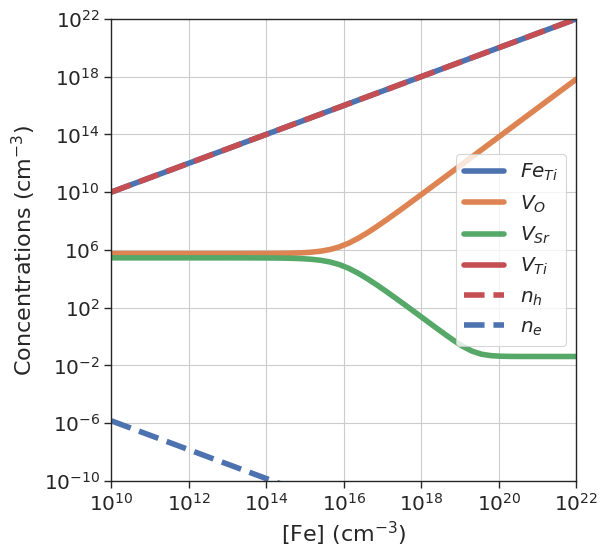

In [9]:
da_Fe.plot_doping_diagram(
                    variable_defect_specie='Fe',
                    concentration_range=(1e10,1e22),
                    chemical_potentials=chempots,
                    bulk_dos=bulk_dos,
                    temperature=1300,
                    quench_temperature=300,
                    figsize=(6,6),
                    fontsize=16,
                    ylim=(1e-10,1e22)
                    );

<Axes: xlabel='Oxygen partial pressure (atm)', ylabel='Concentrations (cm$^{-3})$'>

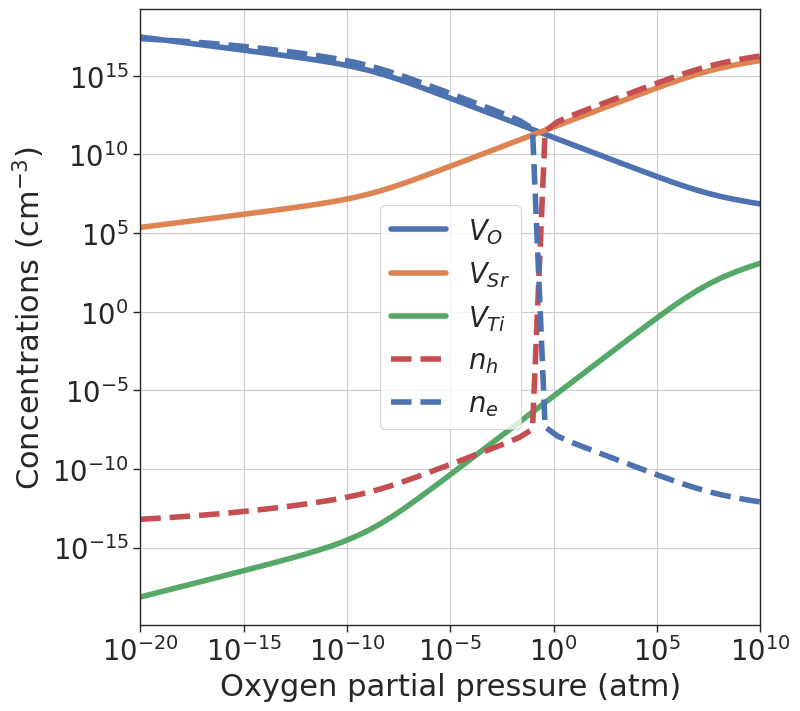

In [10]:
da_int = da.filter_entries(exclude=True,elements=['Fe','Nb'])
precursors = {'SrO':-10,'TiO2':-22}
da_int.plot_brouwer_diagram(bulk_dos=bulk_dos,temperature=1300,quench_temperature=300,precursors=precursors,oxygen_ref=-4.95)

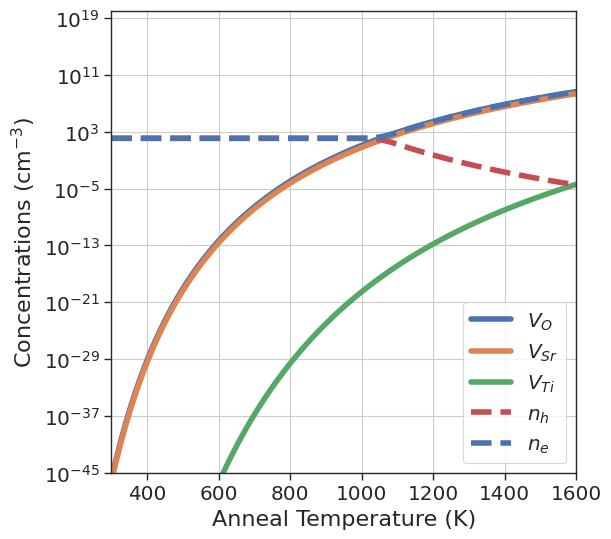

In [14]:
from defermi.thermodynamics import DefectThermodynamics, ThermoData
import numpy as np

dt = DefectThermodynamics(defects_analysis=da_int,bulk_dos=bulk_dos)
T_lim = (300,1600)
temperatures = np.linspace(T_lim[0],T_lim[1],100)
defect_concentrations = []
carrier_concentrations = []
for T in temperatures:
    tdata = dt.get_single_point_quenched_thermodata(chemical_potentials=chempots,initial_temperature=T,final_temperature=300)
    defect_concentrations.append(tdata.defect_concentrations)
    carrier_concentrations.append(tdata.carrier_concentrations)


from defermi.plotter import plot_x_vs_concentrations

plot_x_vs_concentrations(
            x=temperatures,
            xlabel='Anneal Temperature (K)',
            defect_concentrations=defect_concentrations,
            carrier_concentrations=carrier_concentrations,
            xlim=T_lim,
            ylim=(1e-45,1e20),
            figsize=(6,6),
            fontsize=16);